# Практика по базовой математической статистике для Data scientist

# Практика 1 - анализ распределения случайной величины

- Генерация распределений - делаем синтетический датасет по заданным параметрам распределений (пара вариантов из непрерывных функций)
- Построение гистограммы распределения при помощи mathplotlib / seaborn.
- Анализ основных метрик распределения с помощью pandas и numpy - учимся делать выводы по оценкам случайной величины и форме распределения.

Для начала импортируем все полезные библитеки и настроим ноутбук

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.special as sps
import warnings
from scipy.stats import kurtosis
from scipy.stats import skew

%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 7.0)
warnings.filterwarnings("ignore")

Пусть у нас будут два датасета - прибыль по клиентам разных групп, распределенные по нормальному закону N(500,1000) и Гамма закону, параметры которого будет необходимо вычислить на основе средней прибыли = 500 и среднеквадратическому отклонению = 1000.

Сгенерируем синтетические выборки размера ns = 10000 клиентов каждая.

In [2]:
ns = 10000      #размер выборки
n_mean = 500    #средняя прибыль по клиентам
n_sigma = 1000  #средне-квадратичное отклонение

## Работаем с симметричным распределением

Используем имитацию нормального распределения отсюда
https://docs.scipy.org/doc/numpy-1.15.0/reference/generated/numpy.random.normal.html

In [3]:
v = np.random.normal(n_mean, n_sigma, ns)
v = pd.DataFrame(v,columns = ["volume"])
v.volume = round(v.volume,0)

In [0]:
v.head()

,volume
0,-1452.0
1,365.0
2,1097.0
3,1081.0
4,3537.0


Для оценки среднего, среднеквадратического отклонения и квантилей можно воспользоваться отдельными методами pandas и numpy

In [4]:
# Среднее
v.volume.mean()

np.float64(528.2131)

In [5]:
# Медиана
v.volume.median()

np.float64(526.0)

In [6]:
# Мода
v.volume.value_counts().nlargest(10)

volume
538.0     12
692.0     11
303.0     10
173.0     10
573.0     10
1210.0    10
712.0     10
1075.0     9
653.0      9
580.0      9
Name: count, dtype: int64

In [7]:
# Среднеквадратическое отклонение - далее ско
v.volume.std()

np.float64(1003.7955105653208)

In [8]:
#  Квантиль - медиана
np.percentile(v.volume, 50)

np.float64(526.0)

In [9]:
# Кванталь - 0.75
np.percentile(v.volume, 75)

np.float64(1200.25)

Однако, удобнее воспользоваться встроенные методом pandas describe()

In [10]:
v.volume.describe()

count    10000.000000
mean       528.213100
std       1003.795511
min      -3853.000000
25%       -158.000000
50%        526.000000
75%       1200.250000
max       4144.000000
Name: volume, dtype: float64

Здесь мы видим как среднее значение, так максимум, минимум, ско и все полезные квантили.

Теперь построим гистограмму распределения - сделаем это двумя способами, при помощи seaborn и встроенного метода pandas hist()

Text(0.5, 1.0, 'Распределение прибыли по пользователям группы 1')

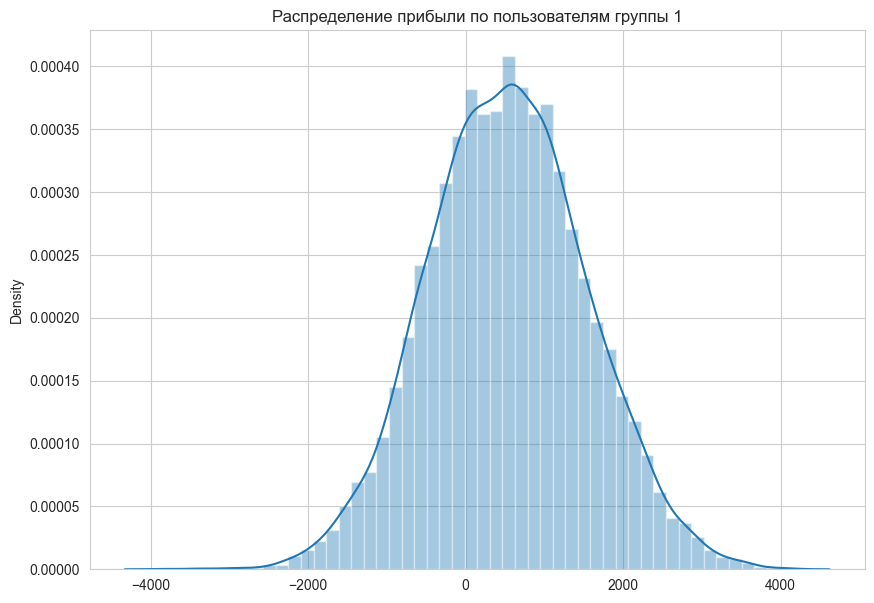

In [11]:
# При помощи seaborn
sns.distplot(v)
plt.title("Распределение прибыли по пользователям группы 1")

Text(0.5, 1.0, 'Распределение прибыли по пользователям группы 1')

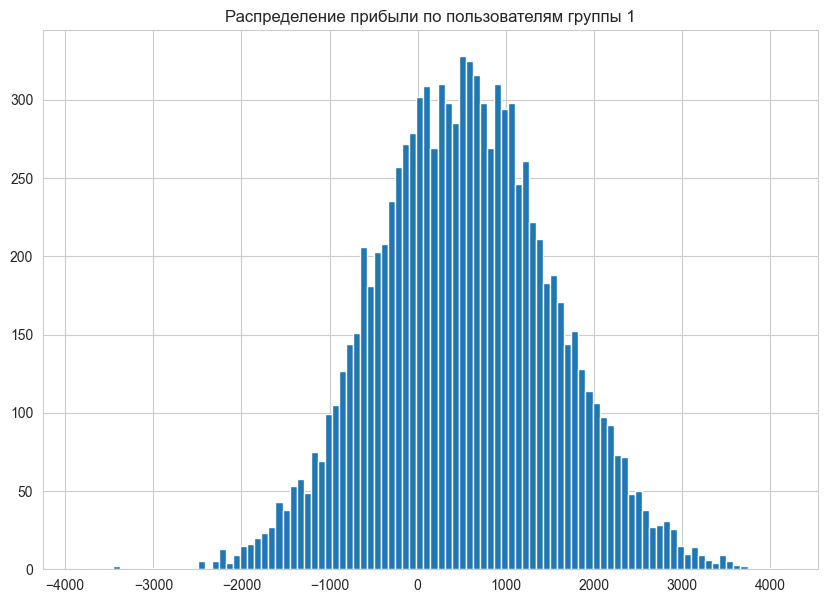

In [12]:
# При помощи pandas
v.volume.hist(bins = 100)
plt.title("Распределение прибыли по пользователям группы 1")

И не забудем про коэффициенты эксцесса и ассиметрии

In [13]:
# Эксцесс
kurtosis(v.volume)

np.float64(-0.011444070226507286)

In [14]:
# Ассиметрия
skew(v.volume)

np.float64(0.0440058875319174)

Теперь объединим все в одну функцию для удобства работы со вторй выборкой

In [15]:
def my_basic_research(df=v, column = "volume"):
    print("Базовые метрики")
    print(df[column].describe())
    print("------------------------------------")
    
    print("Самые популярные значения метрики, топ 5")
    print(df[column].value_counts().nlargest(5))
    print("------------------------------------")
    
    print("Эксцесс ", kurtosis(df[column]))
    print("Ассиметрия ", skew(df[column]))
    
    sns.distplot(df[column])
    plt.title("Распределение прибыли по пользователям")

Базовые метрики
count    10000.000000
mean       528.213100
std       1003.795511
min      -3853.000000
25%       -158.000000
50%        526.000000
75%       1200.250000
max       4144.000000
Name: volume, dtype: float64
------------------------------------
Самые популярные значения метрики, топ 5
volume
538.0    12
692.0    11
303.0    10
173.0    10
573.0    10
Name: count, dtype: int64
------------------------------------
Эксцесс  -0.011444070226507286
Ассиметрия  0.0440058875319174


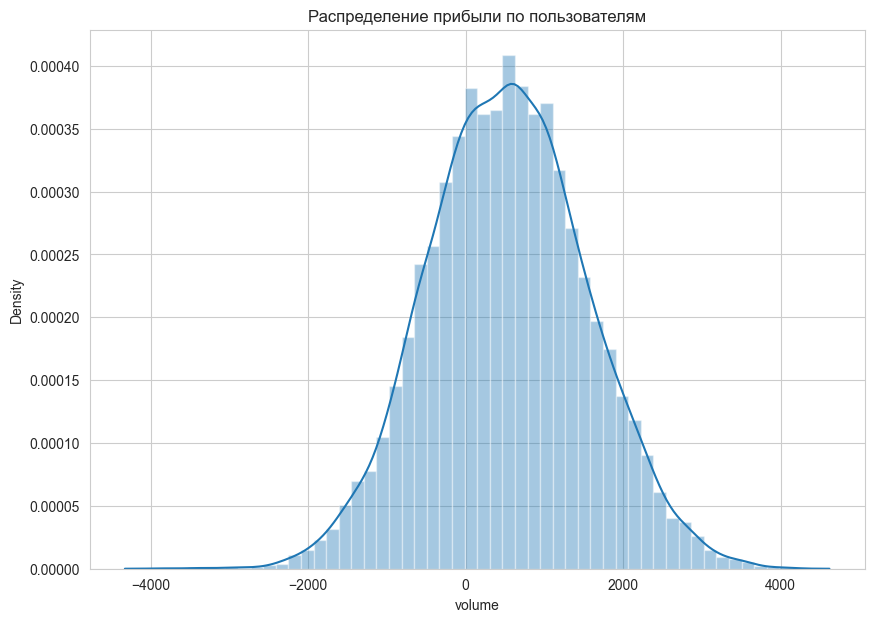

In [16]:
# Опробуем нашу функцию.
my_basic_research()

## Проверим на ассиметричном распределении

Вот так выглядит случай симметричных данных. Но в мире не все распределения симметричны - поэтому попробуем выяснить, чем это нам грозит, повторив анализ для Гамма распределения. Для начала подготовим датасет.

Параметры Гамма закона k и theta связаны со средним и дисперсией этого закона следующим образом (https://ru.wikipedia.org/wiki/Гамма-распределение):

$$m(x)=k*theta$$
$$D(x)=k*theta^2$$

Решая как систему уравнений, получим:

$$ k=(m(x)^2)/D(x)$$
$$theta=D(x)/m(x)$$

Зададим функцию для поиска параметров Гамма распределения по среднему и СКО

In [17]:
def gamma_params(mean, std):
    shape = round((mean/std)**2, 4)
    scale = round((std**2)/mean, 4)
    return (shape, scale)

In [18]:
shape, scale = gamma_params(n_mean, n_sigma)
df = np.random.gamma(shape, scale, ns)
df = pd.DataFrame(df,columns = ["volume"])

# Округлим до целых
df.volume = round(df.volume,0)

In [19]:
df.head()

,volume
0,33.0
1,80.0
2,2516.0
3,6.0
4,0.0


Базовые метрики
count    10000.000000
mean       496.023500
std        995.423488
min          0.000000
25%          5.000000
50%         86.000000
75%        533.000000
max      17560.000000
Name: volume, dtype: float64
------------------------------------
Самые популярные значения метрики, топ 5
volume
0.0    1359
1.0     470
2.0     261
3.0     190
4.0     160
Name: count, dtype: int64
------------------------------------
Эксцесс  30.575320005163654
Ассиметрия  4.314478725015308


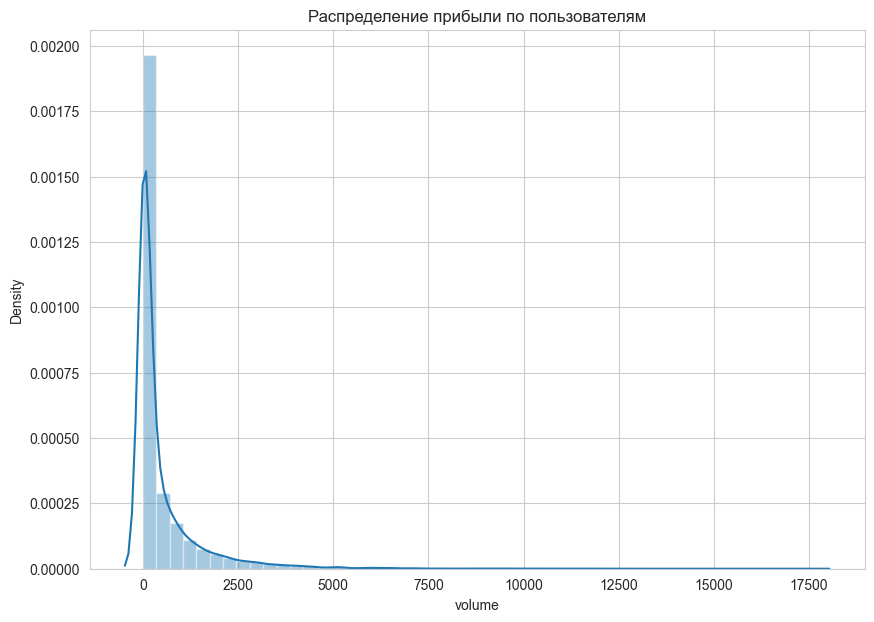

In [20]:
my_basic_research(df = df, column = "volume")

Как можно увидеть, теперь мы имеем дело а ассиметричным распределением и все квантили, а такде коэффициенты ассиметрии и эксцесса поменялись, несмотря на равенство средних и ско - и выводы по этим датасетам получаются абсолютно разные.

К примеру, сравним долю убыточных клиентов для первого и второго датасетов:

In [21]:
v[v.volume < 0].count()/len(v)

volume    0.3054
dtype: float64

In [22]:
df[df.volume < 0].count()/len(df)

volume    0.0
dtype: float64

А теперь сравним суммарную прибыль по клиентам с прибылью свыше медианы в млн:

In [23]:
v[v.volume >= np.percentile(v.volume,50)].volume.sum()/10**6

np.float64(6.657556)

In [24]:
df[df.volume >= np.percentile(df.volume,50)].volume.sum()/10**6

np.float64(4.877222)

Как можно видеть, эффект от ассимерии при одинаковых средних и ско существенно менять выводы.

## Мини домашка

Найдите медиану для Гамма распределения со средним = 1000 и среднеквадратичным отклонением = 3000, не округляя значения синтетического датасета.
Какое число получилось?

In [29]:
n_mean = 1000
n_sigma = 3000

In [30]:
v = np.random.normal(n_mean, n_sigma, ns)
v = pd.DataFrame(v,columns = ["volume"])
v.head()

,volume
0,717.161796
1,2531.594761
2,3274.970364
3,2703.804424
4,5200.638069


In [31]:
v.volume.median()

np.float64(1025.729432090022)

In [34]:
shape, scale = gamma_params(n_mean, n_sigma)
df = np.random.gamma(shape, scale, ns)
df = pd.DataFrame(df,columns = ["volume"])
df.head()

,volume
0,5.124020e+01
1,3.073107e+00
2,2.349723e+00
3,2.016686e-05
4,1.490051e-13


In [33]:
df.volume.median()

np.float64(11.980867771935786)